# 30 April 2026
- notebook to compare raw numbers of CV populations
- comparing Scaringi 1kpc pop from earth to thiele gxy DWD 
- questions
    - how many DWDs are in 150 pc / space density comparions
    - occupation fraction argument: how many CVs vs DWDs are in each LISA freq bin

In [2]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'  # LSS to avoid OOM errors when using jax in this script
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import legwork as lw
import astropy.coordinates as cc
import astropy.units as u
import healpy as hp
import sys
sys.path.append('../scripts/')
import paths
import h5py
import astropy.coordinates as apyco

- load populations (thiele+21 resampled to MW galactic positions)

In [15]:
#dwdthiele = h5py.File('/home/levis/lisa_projects/blip_CVs/datasets/dwd_datasets/results.hdf', 'r')
file = '/home/levis/lisa_projects/blip_CVs/datasets/dwd_datasets/LISA_band_FZ_fiducial_Z.hdf'
dwdthiele = pd.read_hdf(file, key="data")

In [3]:
file = '/home/levis/lisa_projects/blip_CVs/datasets/dwd_datasets/resampled_keepnearby_McMillan_galaxy_Thiele_fiducial_Z.hdf'
dwdrsamp = pd.read_hdf(file)

In [4]:
dwdrsamp

,bin_num,mass_1,mass_2,kstar_1,kstar_2,sep,met,tphys,rad_1,rad_2,xGx,yGx,zGx,FIRE_index,f_gw,dist_sun,i
3,1263015,0.501075,0.303432,10.0,10.0,1.533184,0.000149,6994.793597,0.014209,0.018073,-1.568770,-0.941501,0.407267,10928366,0.000233,6.631787,1.155691
5,809340,0.501969,0.300188,10.0,10.0,1.501786,0.000149,7292.773493,0.014195,0.018157,1.747066,-3.080995,0.888976,10149236,0.000232,10.375197,0.890212
6,987473,0.403565,0.226163,10.0,10.0,0.471942,0.000149,13324.620505,0.015880,0.020392,-1.794865,-3.548112,-0.382400,10149392,0.000575,7.265281,0.756071
55,1052484,0.462991,0.225579,10.0,10.0,0.525720,0.000149,13111.967120,0.014823,0.020412,3.216070,-1.874795,-0.212290,12523873,0.000512,11.494391,1.282918
61,166667,0.465938,0.265998,10.0,10.0,1.112613,0.000149,12976.700008,0.014774,0.019101,-3.985749,4.512979,2.541941,5208995,0.000157,6.620551,1.022159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4645337,72346,1.180072,0.297930,12.0,10.0,2.206538,10.224389,2395.302488,0.005933,0.018215,-2.121073,-2.214044,-0.816911,1924442,0.000104,6.450960,0.872483
4645498,1253219,1.335600,0.617532,12.0,11.0,2.715767,10.503970,269.112511,0.003644,0.012544,11.527803,-3.182534,-0.680895,8752530,0.000176,19.918225,1.241961
4645508,550472,1.281282,0.767352,12.0,11.0,3.151418,10.522170,133.769347,0.004540,0.010690,-3.038487,-4.749968,2.030728,12980996,0.000113,7.241830,0.683243
4645724,60896,1.348848,0.307455,12.0,10.0,2.186425,11.428070,1570.678803,0.003396,0.017971,2.982439,-2.364052,0.009963,13009981,0.000134,11.353300,0.672185


In [5]:
np.sum(dwdrsamp['dist_sun'] < 1)

np.int64(22115)

In [6]:
cvgxyfile = paths.lssdata / 'dat_fullgxy_rs42_final.txt'
cvgxy = pd.read_csv(cvgxyfile)

In [7]:
cvgxy

,# m1[Msun],m2[Msun],f_gw[Hz],inclination[rad],x_galcent[kpc],y_galcent[kpc],z_galcent[kpc],Scar_reassigned,Pala_reassigned,dist_from_sun[kpc]
0,0.700548,0.821742,0.000077,1.370129,3.012746,-7.636290,0.425292,0.0,0.0,9.196793
1,0.700910,0.089096,0.000369,1.146334,-1.995981,-1.512412,-1.443056,0.0,0.0,10.334593
2,0.698234,0.108100,0.000333,1.209398,8.366633,-13.318012,1.254375,0.0,0.0,13.377256
3,0.699642,0.112340,0.000330,0.761463,-2.180671,-9.321401,0.961928,0.0,0.0,13.925489
4,0.699784,0.109918,0.000334,1.329256,-1.870042,4.011498,0.978920,0.0,0.0,10.809764
...,...,...,...,...,...,...,...,...,...,...
3908559,0.698753,0.083772,0.000378,1.386895,-1.568857,2.991821,-0.459733,0.0,0.0,10.153552
3908560,0.699861,0.146772,0.000284,0.475929,5.652759,-1.465680,0.797379,0.0,0.0,2.974634
3908561,0.699762,0.048480,0.000392,0.393419,-9.689314,-6.462087,3.323855,0.0,0.0,19.233087
3908562,0.700860,0.337479,0.000137,1.097728,-0.578329,9.414983,0.702464,0.0,0.0,12.837535


In [8]:
galcentdef = apyco.galactocentric_frame_defaults.get_from_registry('latest')
galcent_sun_dist = galcentdef['parameters']['galcen_distance'].to('kpc').value
galcent_z_sun = galcentdef['parameters']['z_sun'].to('kpc').value

CVdistsun = np.sqrt((cvgxy[' x_galcent[kpc]'] - galcent_sun_dist)**2 + cvgxy[' y_galcent[kpc]']**2 + (cvgxy[' z_galcent[kpc]'] - galcent_z_sun)**2)

In [9]:
print(galcent_sun_dist, galcent_z_sun)

8.122 0.020800000000000003


In [10]:
print(np.min(CVdistsun))
print(np.sum(CVdistsun < 1))

0.7921518257449446
7


In [11]:
np.sum(cvgxy[' dist_from_sun[kpc]'] < 1)

np.int64(7291)

(array([296., 612., 769., 923., 984., 980., 937., 826., 664., 293.]),
 array([15.25448147, 15.45323826, 15.65199505, 15.85075184, 16.04950863,
        16.24826542, 16.44702221, 16.645779  , 16.84453578, 17.04329257,
        17.24204936]),
 <BarContainer object of 10 artists>)

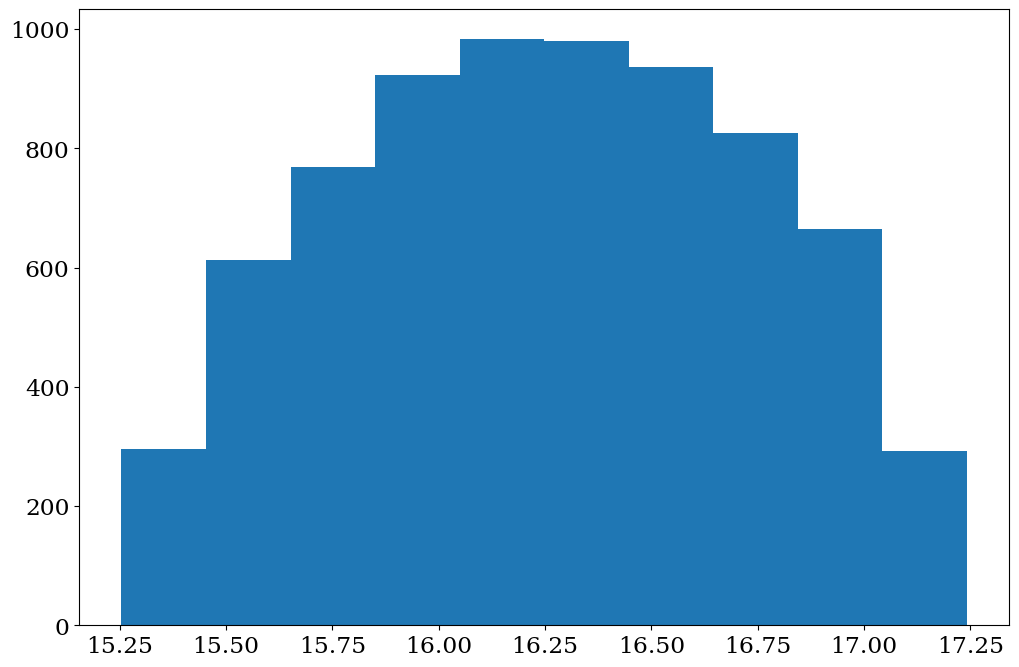

In [12]:
plt.hist(CVdistsun[np.where(cvgxy[' Scar_reassigned'] == 1)[0]])

In [13]:
cvgxy.shape[0] / dwdrsamp.shape[0]

0.3294157506780367

In [14]:
7284/np.sum(dwdrsamp['dist_sun'] < 1)

np.float64(0.3293692064209812)

In [15]:
np.sum(cvgxy[' dist_from_sun[kpc]'] < 1)/np.sum(dwdrsamp['dist_sun'] < 1)

np.float64(0.3296857336649333)

(array([2.0000e+00, 2.0000e+00, 2.0000e+00, 9.0000e+00, 1.7000e+01,
        4.5700e+03, 5.8570e+03, 7.1330e+03, 8.6060e+03, 1.0003e+04,
        1.1730e+04, 1.3166e+04, 1.4828e+04, 1.6472e+04, 1.8091e+04,
        2.0096e+04, 2.1607e+04, 2.3937e+04, 2.6090e+04, 2.7982e+04,
        3.0124e+04, 3.2460e+04, 3.4847e+04, 3.7876e+04, 4.0344e+04,
        4.2589e+04, 4.5543e+04, 4.8253e+04, 5.2011e+04, 5.4394e+04,
        5.8021e+04, 6.1275e+04, 6.4577e+04, 6.8874e+04, 7.1854e+04,
        7.5503e+04, 7.9129e+04, 8.2188e+04, 8.5313e+04, 8.7994e+04,
        9.0521e+04, 9.1457e+04, 9.1236e+04, 9.0729e+04, 8.8813e+04,
        8.7940e+04, 8.4830e+04, 8.3745e+04, 8.0913e+04, 7.8815e+04,
        7.6498e+04, 7.3569e+04, 7.0802e+04, 6.8730e+04, 6.5926e+04,
        6.3896e+04, 6.0792e+04, 5.8666e+04, 5.6085e+04, 5.3586e+04,
        5.1726e+04, 4.8999e+04, 4.6965e+04, 4.4772e+04, 4.2854e+04,
        4.0780e+04, 3.8992e+04, 3.6919e+04, 3.5010e+04, 3.3567e+04,
        3.1878e+04, 3.0685e+04, 2.9271e+04, 2.74

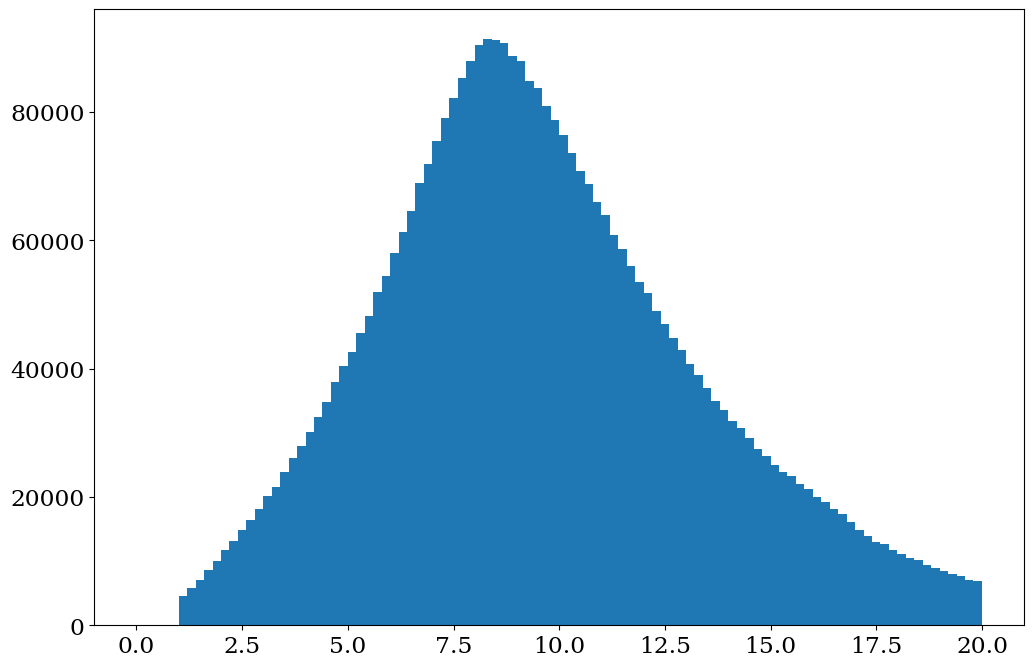

In [85]:
plt.hist(CVdistsun, bins=100, range=(0, 20))

In [ ]:
kpcsph = (4/3)*np.pi*(1*u.kpc)**3
kpccyl = np.pi*(1*u.kpc)**2*2*u.kpc

(array([2.56000e+02, 1.49500e+03, 3.83800e+03, 6.66500e+03, 9.86100e+03,
        1.37280e+04, 1.73920e+04, 2.17220e+04, 2.59140e+04, 3.03100e+04,
        3.51260e+04, 4.00270e+04, 4.45830e+04, 5.00110e+04, 5.47810e+04,
        6.04910e+04, 6.56830e+04, 7.20550e+04, 7.82450e+04, 8.40010e+04,
        9.08480e+04, 9.83440e+04, 1.04856e+05, 1.12629e+05, 1.20577e+05,
        1.28673e+05, 1.38046e+05, 1.46700e+05, 1.55508e+05, 1.66057e+05,
        1.75281e+05, 1.85578e+05, 1.96363e+05, 2.06844e+05, 2.17415e+05,
        2.28324e+05, 2.37788e+05, 2.48565e+05, 2.58644e+05, 2.66822e+05,
        2.72734e+05, 2.76423e+05, 2.75853e+05, 2.73542e+05, 2.68553e+05,
        2.65156e+05, 2.58152e+05, 2.52365e+05, 2.45900e+05, 2.37498e+05,
        2.30624e+05, 2.22736e+05, 2.14482e+05, 2.07012e+05, 1.99209e+05,
        1.92101e+05, 1.84389e+05, 1.76731e+05, 1.69176e+05, 1.62746e+05,
        1.55906e+05, 1.49249e+05, 1.41979e+05, 1.35423e+05, 1.29657e+05,
        1.23236e+05, 1.18524e+05, 1.12727e+05, 1.07

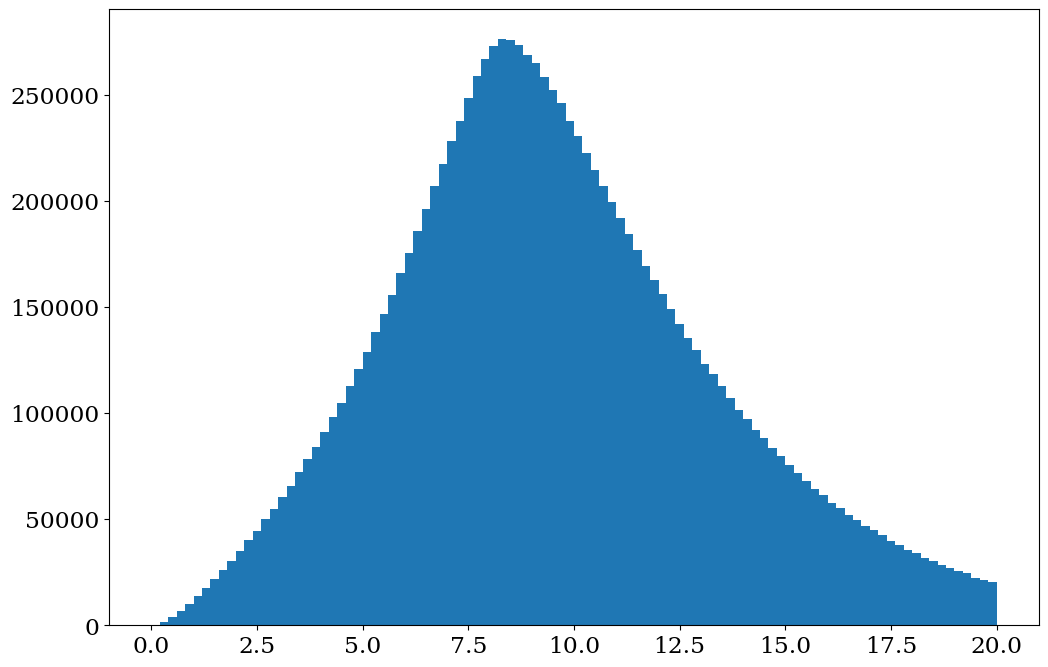

In [75]:
plt.hist(dwdrsamp['dist_sun'], bins=100, range=(0, 20))

In [19]:
dwdthiele

,bin_num,mass_1,mass_2,kstar_1,kstar_2,sep,met,tphys,rad_1,rad_2,xGx,yGx,zGx,FIRE_index,f_gw,dist_sun
3,1263015,0.501075,0.303432,10.0,10.0,1.533184,0.000149,6994.793597,0.014209,0.018073,-1.279441,-151.648062,86.265629,10928366,0.000233,182.084703
5,809340,0.501969,0.300188,10.0,10.0,1.501786,0.000149,7292.773493,0.014195,0.018157,7.597375,12.603761,-5.085130,10149236,0.000232,13.669724
6,987473,0.403565,0.226163,10.0,10.0,0.471942,0.000149,13324.620505,0.015880,0.020392,5.984470,12.335603,-4.585615,10149392,0.000575,10.097694
55,1052484,0.462991,0.225579,10.0,10.0,0.525720,0.000149,13111.967120,0.014823,0.020412,2.177386,14.888761,-6.235602,12523873,0.000512,9.942835
61,166667,0.465938,0.265998,10.0,10.0,1.112613,0.000149,12976.700008,0.014774,0.019101,-0.189949,-2.319661,0.251798,5208995,0.000157,11.041301
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4645337,72346,1.180072,0.297930,12.0,10.0,2.206538,10.224389,2395.302488,0.005933,0.018215,0.593080,0.248334,0.191923,1924442,0.000104,7.704673
4645498,1253219,1.335600,0.617532,12.0,11.0,2.715767,10.503970,269.112511,0.003644,0.012544,25.951664,8.095524,61.848707,8752530,0.000176,82.316373
4645508,550472,1.281282,0.767352,12.0,11.0,3.151418,10.522170,133.769347,0.004540,0.010690,-0.733919,0.856833,-0.212025,12980996,0.000113,7.456449
4645724,60896,1.348848,0.307455,12.0,10.0,2.186425,11.428070,1570.678803,0.003396,0.017971,1.710480,-0.425703,-0.574854,13009981,0.000134,8.709123


In [47]:
galcentdef = apyco.galactocentric_frame_defaults.get_from_registry('latest')
galcent_sun_dist = galcentdef['parameters']['galcen_distance'].to('kpc').value
galcent_z_sun = galcentdef['parameters']['z_sun'].to('kpc').value


distsun = np.sqrt((dwdthiele['xGx']-galcent_sun_dist)**2 + dwdthiele['yGx']**2 + (dwdthiele['zGx']-galcent_z_sun)**2)

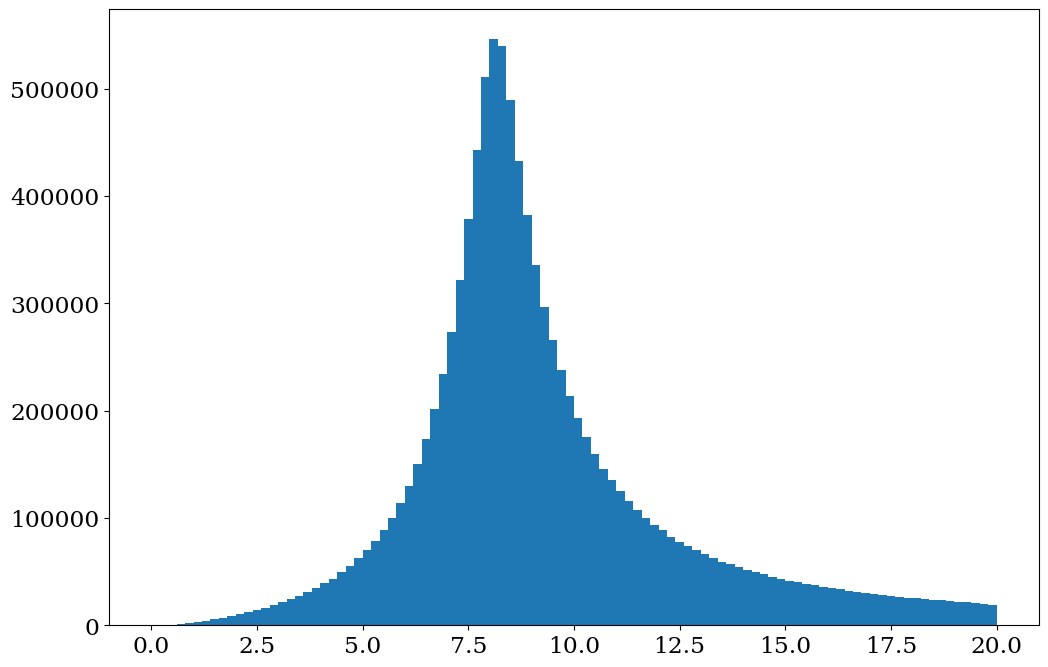

In [48]:
plt.hist(dwdthiele['dist_sun'], bins=100, range=(0, 20));


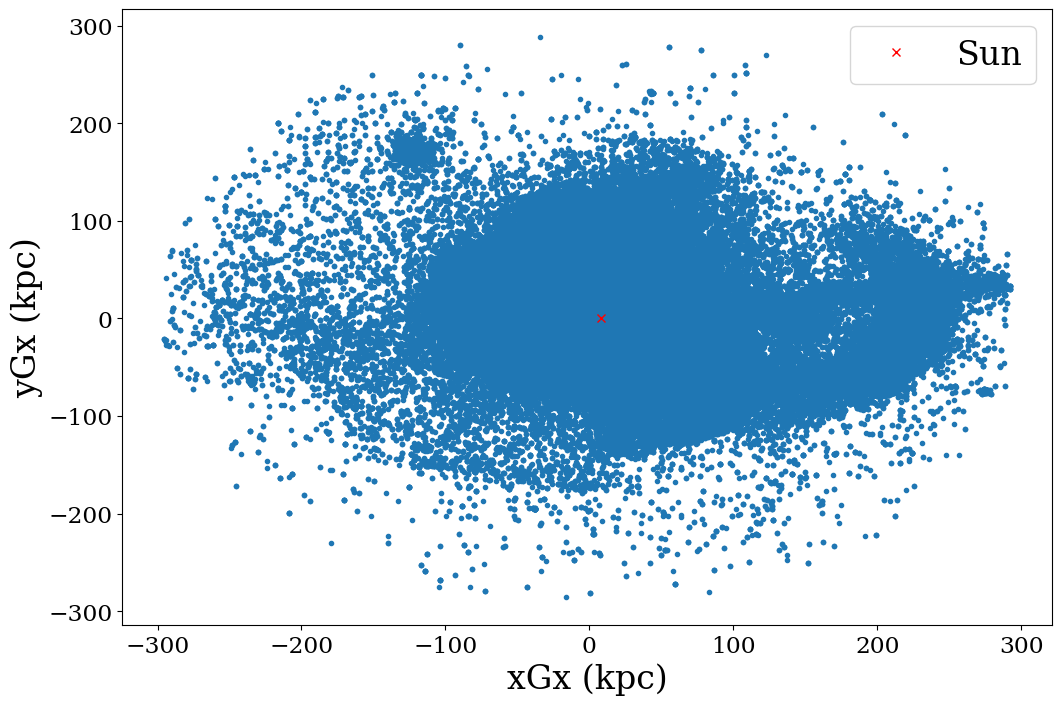

In [49]:
plt.plot(dwdthiele['xGx'], dwdthiele['yGx'], '.');
plt.plot(galcent_sun_dist, 0, 'x', color='red', label='Sun');
plt.xlabel('xGx (kpc)');
plt.ylabel('yGx (kpc)');
plt.legend();

In [56]:
np.array(dwdthiele['xGx'])

array([-1.27944101,  7.59737508,  5.98447002, ..., -0.73391928,
        1.71048005, -6.49142776], shape=(11865140,))

In [60]:
dwdco = apyco.SkyCoord(x=np.array(dwdthiele['xGx'])*u.kpc, y=np.array(dwdthiele['yGx'])*u.kpc, z=np.array(dwdthiele['zGx'])*u.kpc, frame='galactocentric', representation_type='cartesian')

In [62]:
SSBc = dwdco.transform_to(apyco.BarycentricMeanEcliptic)

<Figure size 1200x800 with 0 Axes>

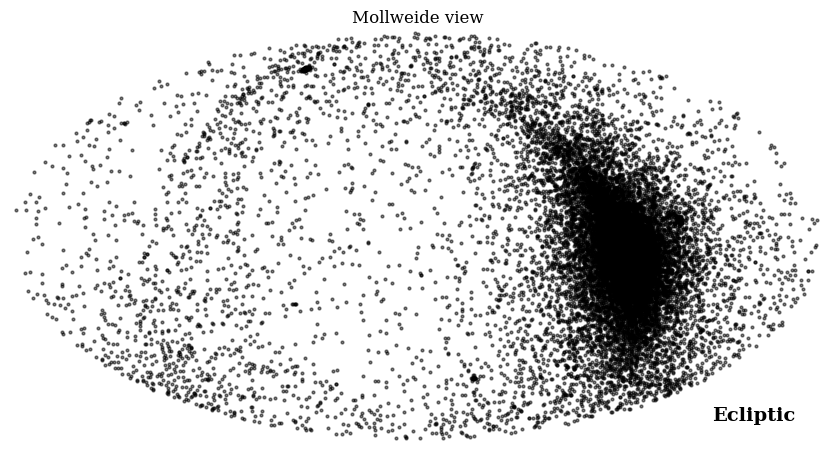

In [63]:
## get latitude, longitude
lat = SSBc.lat.to(u.rad).value
long = SSBc.lon.to(u.rad).value
## check
plt.figure()
hp.mollview(coord='E')
hp.projscatter(long[::500]*u.rad.to(u.deg),lat[::500]*u.rad.to(u.deg),lonlat=True,color='k',alpha=0.5,s=4)
plt.show()

In [40]:
np.mean(dwdthiele['dist_sun'])

np.float64(15.16712180455675)

In [41]:
np.median(dwdthiele['dist_sun'])

np.float64(8.880342674301813)

In [32]:
np.sum(distsun < 1)

np.int64(5540)

In [24]:
kpcfilt = dwdthiele['dist_sun'] < 1
np.sum(kpcfilt)

np.int64(4723)

In [3]:
cvgxy_pop = pd.read_csv(paths.lssdata / 'dat_fullgxy_rs42_final_blip.txt', delim_whitespace=True, names=['f','h','lat','long'])

/tmp/ipykernel_315084/2478737558.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  cvgxy_pop = pd.read_csv(paths.lssdata / 'dat_fullgxy_rs42_final_blip.txt', delim_whitespace=True, names=['f','h','lat','long'])


In [ ]:
dwdco = apyco.SkyCoord(l=dwdthiele['long']*u.rad, b=dwdthiele['lat']*u.rad,  frame='galactic')

,f,h,lat,long
0,0.000323,7.498204e-24,0.889764,5.323162
1,0.000155,5.022706e-24,-0.202589,4.646748
2,0.000141,7.531809e-24,0.034710,4.768507
3,0.000265,2.977497e-23,-0.316984,3.746941
4,0.000394,4.088676e-23,-0.309792,5.422777
...,...,...,...,...
3925409,0.000346,4.726178e-24,0.102754,4.836715
3925410,0.000398,2.686760e-24,-0.302153,4.487336
3925411,0.000392,1.886826e-24,-0.497961,4.407861
3925412,0.000290,5.258901e-24,-0.104571,4.658604
